In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

df1.rename(columns={'Estimated Unemployment Rate (%)':'Unemployment Rate'}, inplace=True)
df2.rename(columns={'Estimated Unemployment Rate (%)':'Unemployment Rate'}, inplace=True)

df1 = df1.dropna()
df2 = df2.dropna()

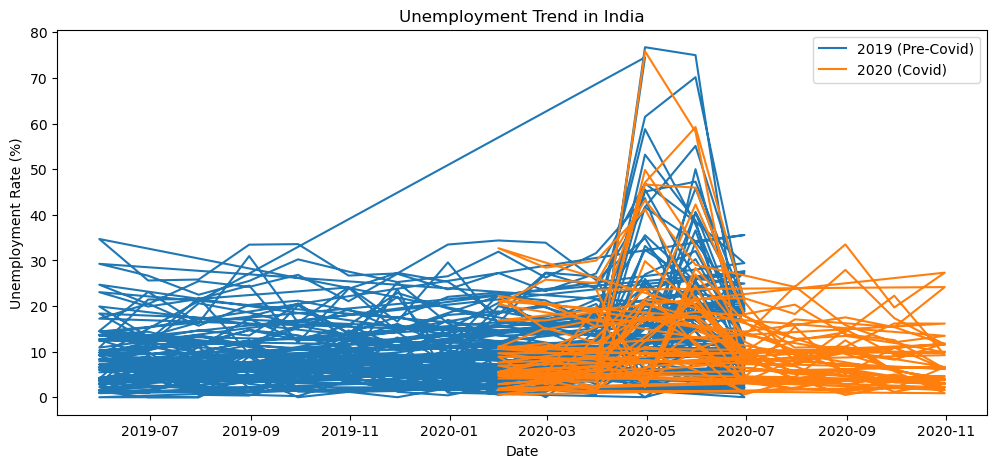

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df1['Date'], df1['Unemployment Rate'], label='2019 (Pre-Covid)')
plt.plot(df2['Date'], df2['Unemployment Rate'], label='2020 (Covid)')
plt.legend()
plt.title("Unemployment Trend in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

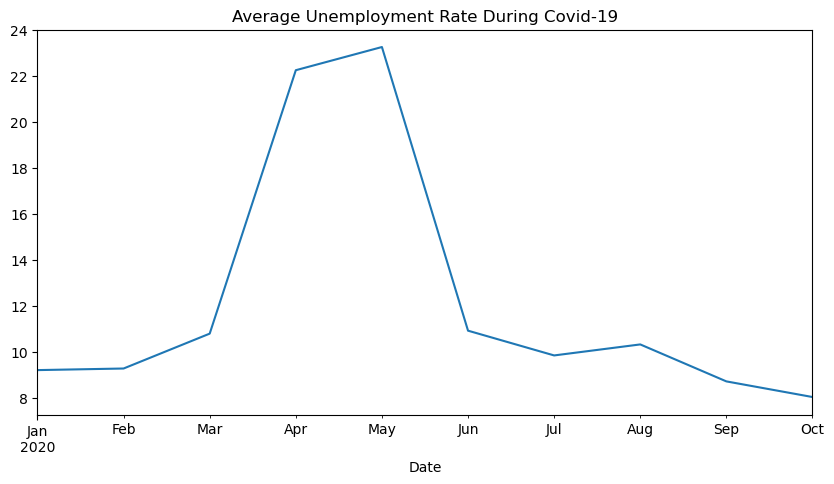

In [6]:
covid_avg = df2.groupby('Date')['Unemployment Rate'].mean()

covid_avg.plot(figsize=(10,5))
plt.title("Average Unemployment Rate During Covid-19")
plt.show()

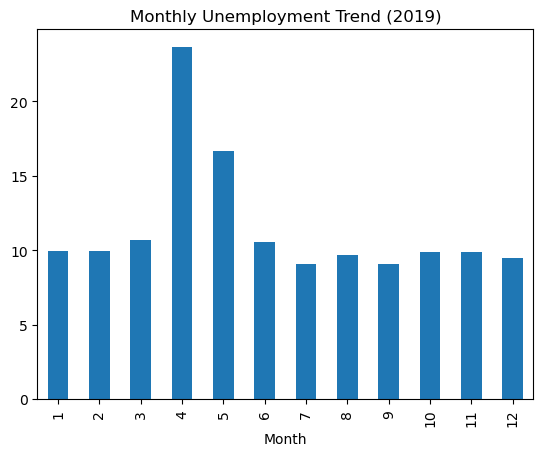

In [8]:
df1['Month'] = df1['Date'].dt.month
monthly_avg = df1.groupby('Month')['Unemployment Rate'].mean()

monthly_avg.plot(kind='bar')
plt.title("Monthly Unemployment Trend (2019)")
plt.show()

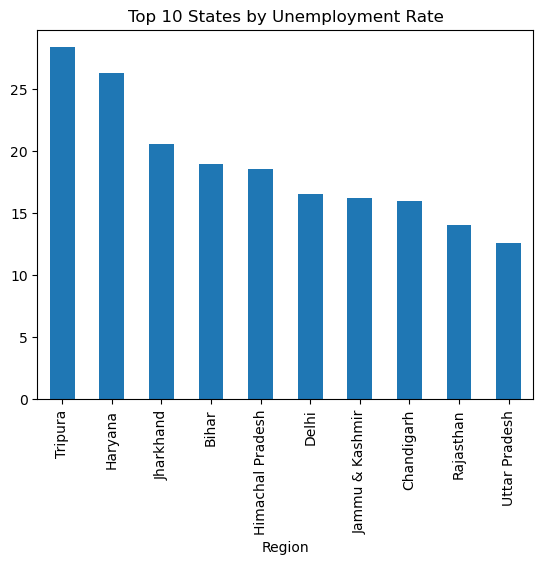

In [11]:
top_states = df1.groupby('Region')['Unemployment Rate'].mean().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title("Top 10 States by Unemployment Rate")
plt.show()

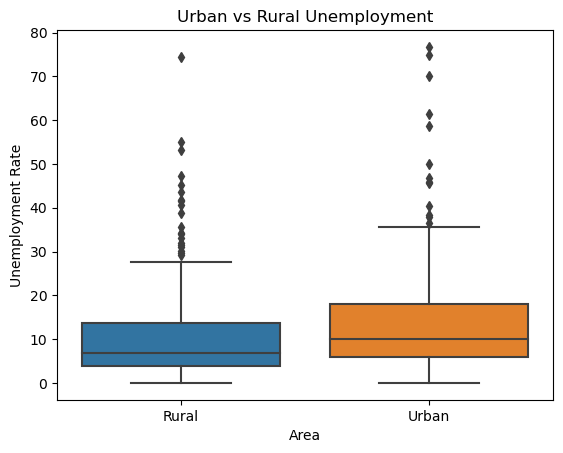

In [12]:
sns.boxplot(data=df1, x='Area', y='Unemployment Rate')
plt.title("Urban vs Rural Unemployment")
plt.show()